In [1]:
# Imports
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
# Batting and pitching dataset with teams
df = pd.read_csv('batting_pitching_combined.csv', delimiter=',')

In [3]:
# list and drop columns that are less related to the target
cols_to_drop = ['name', 'playerid', 'mlbamid', 'team', 'Acronym', 'Full Name_team', 'Full Team Name', 'Drafted By', 'Drafted From', 'team_new', 'division_team', 'id_team', 'team_teamstats', 'Difference_team', 'conf_national_rec_team']
df = df.drop(columns=cols_to_drop)
print(df.columns.tolist())

# convert the target to numerical values
df['Drafted?'] = df['Drafted?'].astype(int)

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'team_old', 'league_team', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team

In [4]:
df.head(10)

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,...,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
0,19.0,A.J. Causey,2022,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,...,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52
1,20.0,A.J. Causey,2023,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,...,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,...,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04
3,20.0,A.J. Colarusso,2024,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,...,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73
4,21.0,A.J. Colarusso,2025,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,...,0.379,428.0,231.0,1.85,7.8,NaN,9.0,0.16,1.60,4.21
5,19.0,A.J. Evasco,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.439,519.0,274.0,1.89,9.4,NaN,11.0,0.19,1.55,4.97
6,NaN,A.J. Martin,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.483,393.0,258.0,1.52,7.7,NaN,13.0,0.25,1.71,5.04
7,19.0,A.J. Mendolia,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.365,272.0,208.0,1.31,5.6,NaN,16.0,0.31,1.84,NaN
8,20.0,A.J. Mendolia,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.296,310.0,266.0,1.17,6.3,NaN,9.0,0.17,1.91,5.38
9,21.0,A.J. Mendolia,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.340,315.0,256.0,1.23,6.3,NaN,14.0,0.27,1.83,5.15


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16728 entries, 0 to 16727
Columns: 125 entries, age to BBPG (Pitching)_team
dtypes: float64(118), int64(3), object(4)
memory usage: 16.0+ MB


In [6]:
player_features = list(df[['age', 'role', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 
                           'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 
                           'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 
                           'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 
                           'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 
                           'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 
                           'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 
                           'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 
                           'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 
                           'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 
                           'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']].columns)

team_features = list(df[['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                         'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 
                         'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team', '2B_team', '2BPG_team', 
                         'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team', 'PO_team', 'A_team', 
                         'E_team', 'FPCT_team', 'HB_team', 'HBP_team', 'HA_team', 'HAPG_team', 'HR_team', 
                         'HRPG_team', 'SF_team', 'SH_team', 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 
                         'R (Batting)_team', 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team', 
                         'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team', '3B_team', '3BPG_team', 
                         'WHIP_team', 'BBPG (Pitching)_team']].columns)

redundant_features = ['k%_pitch', 'bb%_pitch', 'K/BB_team', 'k/bb_pitch']

# IGNORE
#lasso_selected_features = [
#    'age', 'fip', 'K/9', 'WHIP', 'so', 'g', 'L', 'hr/9', 'wp', 'l', 'ER',
#    'HRPG', 'SF', 'babip', 'SHO', 'A', 'bk', 'BB (Pitching)', 'PE', '3B',
#    'ip', 'FPCT', 'CS', 'w', 'HB', 'DPPG', 'SH', 'T', 'SO', 'BBPG (Pitching)',
#    'SBPG', 'cg', 'RPG', 'k-bb%', 'HBP', '2BPG', 'sho', 'e-f', 'lob%', 'sv', 'E'
#]
# lasso_selected_features = [f for f in lasso_selected_features if f not in redundant_features]
#features = lasso_selected_features

features = player_features + team_features
features = [f for f in features if f not in redundant_features]
mapping = {
    'Pitcher': 0,
    'Batter': 1,
    'Both': 2
}

df['role'] = df['role'].map(mapping)

df = pd.get_dummies(df, columns=['league_team'], drop_first=True)
df = pd.get_dummies(df, columns=['team_old'], drop_first=True)

X = df[features]
y = df['Drafted?'].astype(int)

In [7]:
X.head(10)

,age,role,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,...,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
0,19.0,0.0,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,...,805.0,0.432,450.0,245.0,8.3,NaN,10.0,0.18,1.59,4.52
1,20.0,0.0,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,...,965.0,0.482,474.0,257.0,8.8,NaN,13.0,0.23,1.60,4.78
2,21.0,0.0,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,...,1494.0,0.607,700.0,210.0,10.1,1.0,9.0,0.12,1.25,3.04
3,20.0,0.0,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,...,734.0,0.423,409.0,241.0,8.0,NaN,9.0,0.17,1.70,4.73
4,21.0,0.0,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,...,696.0,0.379,428.0,231.0,7.8,NaN,9.0,0.16,1.60,4.21
5,19.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,862.0,0.439,519.0,274.0,9.4,NaN,11.0,0.19,1.55,4.97
6,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,897.0,0.483,393.0,258.0,7.7,NaN,13.0,0.25,1.71,5.04
7,19.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,634.0,0.365,272.0,208.0,5.6,NaN,16.0,0.31,1.84,NaN
8,20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,503.0,0.296,310.0,266.0,6.3,NaN,9.0,0.17,1.91,5.38
9,21.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,592.0,0.340,315.0,256.0,6.3,NaN,14.0,0.27,1.83,5.15


In [8]:
# Separate the two classes
drafted_indices = df[df['Drafted?'] == 1].index
not_drafted_indices = df[df['Drafted?'] == 0].index

print(f"Original class distribution:")
print(f"  Class 0 (Not Drafted): {len(not_drafted_indices)}")
print(f"  Class 1 (Drafted): {len(drafted_indices)}")

# Randomly sample from class 0 to match class 1 size
np.random.seed(42)  # for reproducibility
undersampled_not_drafted = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)

# Combine the balanced indices
balanced_indices = np.concatenate([drafted_indices, undersampled_not_drafted])
np.random.shuffle(balanced_indices)

# Create balanced dataset
X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print(f"\nBalanced class distribution:")
print(f"  Class 0 (Not Drafted): {sum(y_balanced == 0)}")
print(f"  Class 1 (Drafted): {sum(y_balanced == 1)}")
print(f"  Total samples: {len(y_balanced)}")
print(f"  Class 1 percentage: {sum(y_balanced == 1) / len(y_balanced) * 100:.1f}%")

Original class distribution:
  Class 0 (Not Drafted): 15290
  Class 1 (Drafted): 1438

Balanced class distribution:
  Class 0 (Not Drafted): 1438
  Class 1 (Drafted): 1438
  Total samples: 2876
  Class 1 percentage: 50.0%


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

In [10]:
# Show training class distribution and compute scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

print(f"\nTraining set distribution:")
print(f"  Class 0: {neg_count}")
print(f"  Class 1: {pos_count}")
print(f"  Scale_pos_weight: {scale_pos_weight:.2f}")


Training set distribution:
  Class 0: 1150
  Class 1: 1150
  Scale_pos_weight: 1.00


In [11]:
# Train XGBoost classifier on balanced training set
draft_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

draft_model.fit(X_train, y_train)

y_pred = draft_model.predict(X_test)
y_proba = draft_model.predict_proba(X_test)[:,1]

print("\nDrafted? Classifier Results (Balanced Dataset):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))


Drafted? Classifier Results (Balanced Dataset):
Accuracy: 0.877

              precision    recall  f1-score   support

           0      0.892     0.858     0.874       288
           1      0.863     0.896     0.879       288

    accuracy                          0.877       576
   macro avg      0.877     0.877     0.877       576
weighted avg      0.877     0.877     0.877       576



In [12]:
# Show top features by importance from the trained classifier
importance = draft_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importance_df.head(20))


Top 20 Features by Importance:
                   Feature  Importance
0                      age   19.974627
59                 wrc_bat   18.145241
19                so_pitch    6.210718
54                 ops_bat    5.616909
68                  T_team    5.394620
38                   r_bat    4.604422
53                 slg_bat    4.036736
108                TP_team    3.965760
64          conf_rank_team    3.933104
63           conf_rpi_team    3.803440
107               K/9_team    3.680589
65   conf_national_wp_team    3.608070
37                  hr_bat    3.265769
39                 rbi_bat    2.857826
28               fip_pitch    2.831322
20               k/9_pitch    2.830017
60                wraa_bat    2.813438
23             k-bb%_pitch    2.352181
111              WHIP_team    2.209878
50                  k%_bat    2.122458


In [13]:
# Now to set up for pick prediction among drafted players

target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

# Keep only drafted players
drafted_df = df[df[target_drafted] == 1].copy()
pd.options.display.max_columns = None
display(drafted_df.head(5))

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,league_team_ASUN,league_team_America East,league_team_Atlantic 10,league_team_Big 12,league_team_Big East,league_team_Big South,league_team_Big Ten,league_team_Big West,league_team_CAA,league_team_CUSA,league_team_DI Independent,league_team_Horizon,league_team_Ivy League,league_team_MAAC,league_team_MAC,league_team_MEAC,league_team_MVC,league_team_Mountain West,league_team_NEC,league_team_OVC,league_team_Pac-12,league_team_Patriot,league_team_SEC,league_team_SWAC,league_team_SoCon,league_team_Southland,league_team_Summit League,league_team_Sun Belt,league_team_The American,league_team_WAC,league_team_WCC,team_old_Abilene Christian,team_old_Air Force,team_old_Akron,team_old_Alabama,team_old_Alabama A&M,team_old_Alabama St.,team_old_Alcorn,team_old_App State,team_old_Arizona,team_old_Arizona St.,team_old_Ark.-Pine Bluff,team_old_Arkansas,team_old_Arkansas St.,team_old_Army West Point,team_old_Auburn,team_old_Austin Peay,team_old_BYU,team_old_Ball St.,team_old_Baylor,team_old_Bellarmine,team_old_Belmont,team_old_Bethune-Cookman,team_old_Binghamton,team_old_Boston College,team_old_Bowling Green,team_old_Bradley,team_old_Brown,team_old_Bryant,team_old_Bucknell,team_old_Butler,team_old_CSU Bakersfield,team_old_CSUN,team_old_Cal Poly,team_old_Cal St. Fullerton,team_old_California,team_old_California Baptist,team_old_Campbell,team_old_Central Conn. St.,team_old_Central Mich.,team_old_Charleston So.,team_old_Charlotte,team_old_Cincinnati,team_old_Clemson,team_old_Coastal Carolina,team_old_Col. of Charleston,team_old_Columbia,team_old_Coppin St.,team_old_Cornell,team_old_Creighton,team_old_DBU,team_old_Dartmouth,team_old_Davidson,team_old_Dayton,team_old_Delaware,team_old_Delaware St.,team_old_Duke,team_old_ETSU,team_old_East Carolina,team_old_Eastern Ill.,team_old_Eastern Ky.,team_old_Eastern Mich.,team_old_Elon,team_old_Evansville,team_old_FDU,team_old_FGCU,team_old_FIU,team_old_Fairfield,team_old_Fla. Atlantic,team_old_Florida,team_old_Florida A&M,team_old_Florida St.,team_old_Fordham,team_old_Fresno St.,team_old_Ga. Southern,team_old_Gardner-Webb,team_old_George Mason,team_old_George Washington,team_old_Georgetown,team_old_Georgia,team_old_Georgia St.,team_old_Georgia Tech,team_old_Gonzaga,team_old_Grambling,team_old_Grand Canyon,team_old_Hartford,team_old_Harvard,team_old_Hawaii,team_old_High Point,team_old_Hofstra,team_old_Holy Cross,team_old_Houston,team_old_Houston Christian,team_old_Illinois,team_old_Illinois St.,team_old_Indiana,team_old_Indiana St.,team_old_Iona,team_old_Iowa,team_old_Jackson St.,team_old_Jacksonville,team_old_Jacksonville St.,team_old_James Madison,team_old_Kansas,team_old_Kennesaw St.,team_old_Kent St.,team_old_Kentucky,team_old_LIU,team_old_LMU,team_old_LSU,team_old_La Salle,team_old_Lafayette,team_old_Lamar University,team_old_Lehigh,team_old_Liberty,team_old_Lipscomb,team_old_Little Rock,team_old_Long Beach St.,te

In [14]:
# Create college-only rank as target for each year
# Filter to college players only and rank within each year
drafted_df = df[df[target_drafted] == 1].copy()

# Create college-only draft order within each year
drafted_df = drafted_df.sort_values([year_col, target_pick])
drafted_df['College_Draft_Order'] = drafted_df.groupby(year_col).cumcount() + 1

# Normalize to 0-1 so rankings are comparable across years with different class sizes
drafted_df['College_Draft_Pct'] = drafted_df.groupby(year_col)['College_Draft_Order'].transform(
    lambda x: (x - 1) / (len(x) - 1) if len(x) > 1 else 0.5
)

print("College draft order examples:")
print(drafted_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'College_Draft_Pct']].head(15))
print(f"\nPlayers per year:")
print(drafted_df.groupby(year_col).size())

College draft order examples:
       year         nameascii  Pick  College_Draft_Order  College_Draft_Pct
6841   2021       Henry Davis   1.0                    1           0.000000
7394   2021       Jack Leiter   2.0                    2           0.003460
4148   2021     Colton Cowser   5.0                    3           0.006920
14167  2021       Sam Bachman   9.0                    4           0.010381
10308  2021      Kumar Rocker  10.0                    5           0.013841
16189  2021       Will Bednar  14.0                    6           0.017301
14161  2021       Sal Frelick  15.0                    7           0.020761
11975  2021  Michael McGreevy  18.0                    8           0.024221
6688   2021    Gunnar Hoglund  19.0                    9           0.027682
15488  2021      Trey Sweeney  20.0                   10           0.031142
6427   2021    Gavin Williams  23.0                   11           0.034602
13841  2021       Ryan Cusick  24.0                   12  

In [15]:
# XGBoost regression to predict college draft order, using just College_Draft_Order as target (not pick number)

test_year = drafted_df[year_col].max()

train_df = drafted_df[drafted_df[year_col] < test_year]
test_df  = drafted_df[drafted_df[year_col] == test_year]

pick_features = [f for f in features if f not in redundant_features]

X_train = train_df[pick_features]
y_train = train_df['College_Draft_Order']

X_test = test_df[pick_features]
y_test_order = test_df['College_Draft_Order']

model_rank = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

model_rank.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test_order)],
    verbose=50
)

preds = model_rank.predict(X_test)
pred_order = pd.Series(preds).rank(method='min').astype(int).values
actual_order = y_test_order.values

print(f"College draft class sizes per year:")
print(drafted_df.groupby(year_col).size())

corr_order, _ = spearmanr(actual_order, pred_order)
mae_order = mean_absolute_error(actual_order, pred_order)

print(f"\nCollege-Only Rank Model — Raw Order Target (n={len(y_test_order)}):")
print(f"  Spearman: {corr_order:.3f}")
print(f"  MAE:      {mae_order:.1f}")

[0]	validation_0-mae:68.54197
[50]	validation_0-mae:53.34595
[100]	validation_0-mae:48.69038
[150]	validation_0-mae:46.81750
[200]	validation_0-mae:46.13191
[250]	validation_0-mae:45.86251
[300]	validation_0-mae:45.50192
[341]	validation_0-mae:45.59247
College draft class sizes per year:
year
2021    290
2022    297
2023    301
2024    274
2025    276
dtype: int64

College-Only Rank Model — Raw Order Target (n=276):
  Spearman: 0.700
  MAE:      47.8


In [16]:
# Show top features by importance from the trained classifier
importance = model_rank.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importance_df.head(20))


Top 20 Features by Importance:
                   Feature     Importance
0                      age  108914.406250
59                 wrc_bat   87045.390625
19                so_pitch   76167.359375
23             k-bb%_pitch   68687.671875
105                SO_team   55950.550781
64          conf_rank_team   48688.992188
63           conf_rpi_team   45112.218750
38                   r_bat   44101.679688
51                bb/k_bat   43956.175781
84                 PO_team   43938.593750
5                 gs_pitch   42341.121094
107               K/9_team   41265.300781
65   conf_national_wp_team   39632.820312
28               fip_pitch   39578.988281
25              whip_pitch   35839.632812
60                wraa_bat   35262.421875
110              WHIP_team   32636.312500
54                 ops_bat   32067.019531
62                wrc+_bat   30793.669922
37                  hr_bat   28956.845703


In [17]:
# Build results dataframe
results_rank_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_College_Order': pred_order,
    'Actual_College_Order': actual_order,
    'Actual_Pick': y_test_order.values,
})

results_rank_df = results_rank_df.sort_values('Actual_College_Order').reset_index(drop=True)

print(f"Player College Draft Order Predictions (Test Year: {test_year})")
print(f"Total college draftees: {len(results_rank_df)}\n")
display(results_rank_df.head(20))

Player College Draft Order Predictions (Test Year: 2025)
Total college draftees: 276



,name,Predicted_College_Order,Actual_College_Order,Actual_Pick
0,Kade Anderson,3,1,1
1,Liam Doyle,2,2,2
2,Aiva Arquette,12,3,3
3,Jamie Arnold,7,4,4
4,Gavin Kilen,13,5,5
5,Kyson Witherspoon,5,6,6
6,Marek Houston,20,7,7
7,Ike Irish,4,8,8
8,Andrew Fischer,1,9,9
9,Jace LaViolette,28,10,10


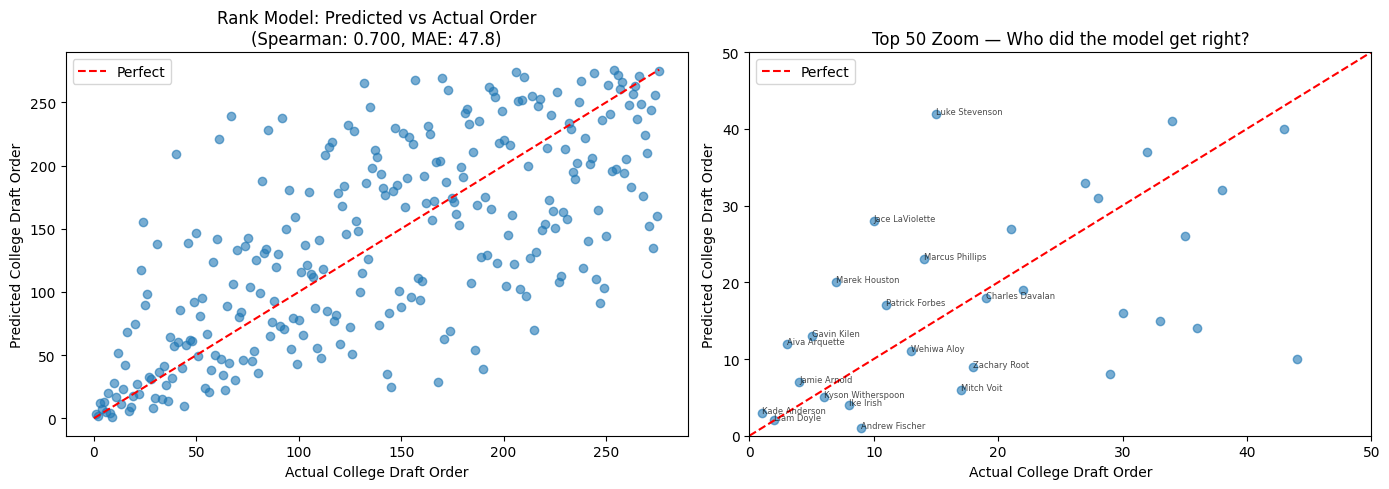

In [18]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_test = len(actual_order)

axes[0].scatter(actual_order, pred_order, alpha=0.6)
axes[0].plot([0, n_test], [0, n_test], 'r--', label='Perfect')
axes[0].set_xlabel('Actual College Draft Order')
axes[0].set_ylabel('Predicted College Draft Order')
axes[0].set_title(f'Rank Model: Predicted vs Actual Order\n(Spearman: {corr_order:.3f}, MAE: {mae_order:.1f})')
axes[0].legend()

axes[1].scatter(actual_order, pred_order, alpha=0.6)
# Add player labels for top 20
for _, row in results_rank_df.head(20).iterrows():
    if row['Actual_College_Order'] <= 20 or row['Predicted_College_Order'] <= 20:
        axes[1].annotate(row['name'], (row['Actual_College_Order'], row['Predicted_College_Order']),
                         fontsize=6, alpha=0.7)
axes[1].plot([0, 50], [0, 50], 'r--', label='Perfect')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)
axes[1].set_xlabel('Actual College Draft Order')
axes[1].set_ylabel('Predicted College Draft Order')
axes[1].set_title('Top 50 Zoom — Who did the model get right?')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
prospects = pd.read_csv('mlb_2025_draft_prospects_top250.csv')

# Compare with MLB Pipeline on matched players
results_rank_df['name_clean'] = results_rank_df['name'].str.strip().str.lower()
prospects['name_clean'] = prospects['name'].str.strip().str.lower()

comp = results_rank_df.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')

# Re-rank everything among only matched players
comp = comp.sort_values('Actual_Pick').reset_index(drop=True)
comp['Actual_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('Predicted_College_Order').reset_index(drop=True)
comp['Pred_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('rank').reset_index(drop=True)
comp['Pipeline_Order_Matched'] = range(1, len(comp) + 1)

corr_you, _ = spearmanr(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
corr_pipe, _ = spearmanr(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])
mae_you = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
mae_pipe = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])

print(f"Head-to-Head on Matched College Players (n={len(comp)})")
print(f"{'Comparison':<45} {'Spearman':>10} {'MAE':>10}")
print("-" * 65)
print(f"{'Your Rank Model vs Actual':<45} {corr_you:>10.3f} {mae_you:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<45} {corr_pipe:>10.3f} {mae_pipe:>10.1f}")

comp = comp[['name', 'Pipeline_Order_Matched', 'Predicted_College_Order', 'Actual_College_Order']].copy()
comp.columns = ['name', 'MLB_Pipeline_College_Order', 'Predicted_College_Order', 'Actual_College_Order']
display(comp.sort_values('Actual_College_Order').reset_index(drop=True).head(25))

Head-to-Head on Matched College Players (n=99)
Comparison                                      Spearman        MAE
-----------------------------------------------------------------
Your Rank Model vs Actual                          0.661       17.7
MLB Pipeline vs Actual                             0.837       11.6


,name,MLB_Pipeline_College_Order,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,1,3,1
1,Liam Doyle,4,2,2
2,Aiva Arquette,3,12,3
3,Jamie Arnold,2,7,4
4,Gavin Kilen,11,13,5
5,Kyson Witherspoon,5,5,6
6,Marek Houston,7,20,7
7,Ike Irish,6,4,8
8,Andrew Fischer,12,1,9
9,Jace LaViolette,10,28,10


In [20]:
# Filter to top 50 college draftees only
top_n = 50

# From your rank model results
top50 = results_rank_df[results_rank_df['Actual_College_Order'] <= top_n].copy()

# Re-rank predictions among only these top 50
top50 = top50.sort_values('Predicted_College_Order').reset_index(drop=True)
top50['Pred_Order_Top50'] = range(1, len(top50) + 1)

corr_top50, _ = spearmanr(top50['Actual_College_Order'], top50['Pred_Order_Top50'])
mae_top50 = mean_absolute_error(top50['Actual_College_Order'], top50['Pred_Order_Top50'])

print(f"Top {top_n} College Draftees Only (n={len(top50)})")
print(f"  Spearman: {corr_top50:.3f}")
print(f"  MAE:      {mae_top50:.1f}")

display(top50[['name', 'Actual_College_Order', 'Pred_Order_Top50', 'Actual_Pick']].sort_values('Actual_College_Order').reset_index(drop=True).head(20))

Top 50 College Draftees Only (n=50)
  Spearman: 0.608
  MAE:      10.1


,name,Actual_College_Order,Pred_Order_Top50,Actual_Pick
0,Kade Anderson,1,3,1
1,Liam Doyle,2,2,2
2,Aiva Arquette,3,12,3
3,Jamie Arnold,4,7,4
4,Gavin Kilen,5,13,5
5,Kyson Witherspoon,6,5,6
6,Marek Houston,7,20,7
7,Ike Irish,8,4,8
8,Andrew Fischer,9,1,9
9,Jace LaViolette,10,24,10


In [21]:
# Head-to-head vs Pipeline on top 50 matched players
top50['name_clean'] = top50['name'].str.strip().str.lower()

comp50 = top50.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')

# Re-rank among only matched top players
comp50 = comp50.sort_values('Actual_College_Order').reset_index(drop=True)
comp50['Actual_Order_M'] = range(1, len(comp50) + 1)

comp50 = comp50.sort_values('Predicted_College_Order').reset_index(drop=True)
comp50['Pred_Order_M'] = range(1, len(comp50) + 1)

comp50 = comp50.sort_values('rank').reset_index(drop=True)
comp50['Pipeline_Order_M'] = range(1, len(comp50) + 1)

corr_you_50, _ = spearmanr(comp50['Actual_Order_M'], comp50['Pred_Order_M'])
corr_pipe_50, _ = spearmanr(comp50['Actual_Order_M'], comp50['Pipeline_Order_M'])
mae_you_50 = mean_absolute_error(comp50['Actual_Order_M'], comp50['Pred_Order_M'])
mae_pipe_50 = mean_absolute_error(comp50['Actual_Order_M'], comp50['Pipeline_Order_M'])

print(f"Head-to-Head — Top College Draftees Matched (n={len(comp50)})")
print(f"{'Comparison':<45} {'Spearman':>10} {'MAE':>10}")
print("-" * 65)
print(f"{'Your Rank Model vs Actual':<45} {corr_you_50:>10.3f} {mae_you_50:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<45} {corr_pipe_50:>10.3f} {mae_pipe_50:>10.1f}")

comp50 = comp50[['name', 'Pipeline_Order_M', 'Predicted_College_Order', 'Actual_College_Order']].copy()
comp50.columns = ['name', 'MLB_Pipeline_College_Order', 'Predicted_College_Order', 'Actual_College_Order']
display(comp50.sort_values('Actual_College_Order').reset_index(drop=True).head(25))

Head-to-Head — Top College Draftees Matched (n=49)
Comparison                                      Spearman        MAE
-----------------------------------------------------------------
Your Rank Model vs Actual                          0.613        9.8
MLB Pipeline vs Actual                             0.874        5.1


,name,MLB_Pipeline_College_Order,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,1,3,1
1,Liam Doyle,4,2,2
2,Aiva Arquette,3,12,3
3,Jamie Arnold,2,7,4
4,Gavin Kilen,11,13,5
5,Kyson Witherspoon,5,5,6
6,Marek Houston,7,20,7
7,Ike Irish,6,4,8
8,Andrew Fischer,12,1,9
9,Jace LaViolette,10,28,10


KeyError: 'Actual_Order_M'

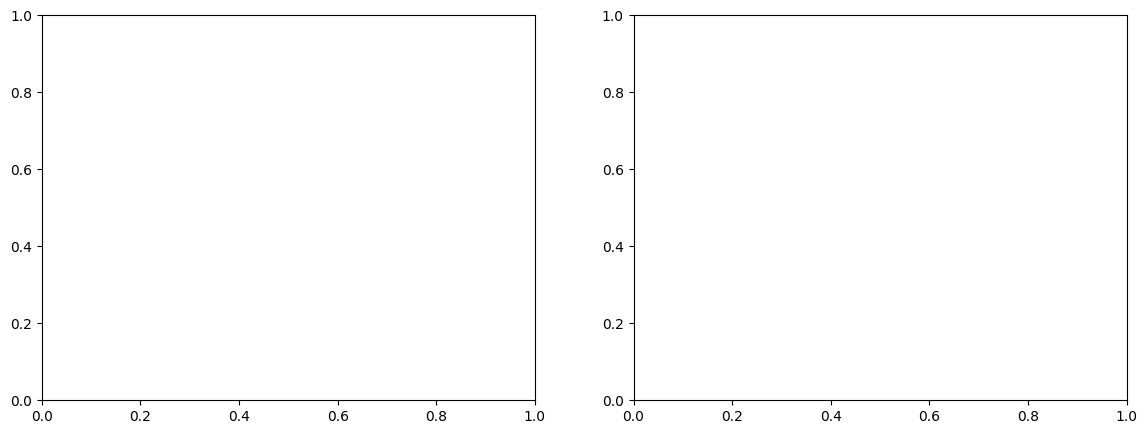

In [22]:
# Scatter plots for top 50
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n = len(comp50)

axes[0].scatter(comp50['Actual_Order_M'], comp50['Pred_Order_M'], alpha=0.6)
axes[0].plot([0, n], [0, n], 'r--', label='Perfect')
for _, row in comp50.iterrows():
    if row['Actual_Order_M'] <= 10 or row['Pred_Order_M'] <= 10:
        axes[0].annotate(row['name'], (row['Actual_Order_M'], row['Pred_Order_M']),
                         fontsize=7, alpha=0.7)
axes[0].set_xlabel('Actual College Order')
axes[0].set_ylabel('Predicted College Order')
axes[0].set_title(f'Your Model vs Actual (Top College)\n(Spearman: {corr_you_50:.3f}, MAE: {mae_you_50:.1f})')
axes[0].legend()

axes[1].scatter(comp50['Actual_Order_M'], comp50['Pipeline_Order_M'], alpha=0.6, color='orange')
axes[1].plot([0, n], [0, n], 'r--', label='Perfect')
for _, row in comp50.iterrows():
    if row['Actual_Order_M'] <= 10 or row['Pipeline_Order_M'] <= 10:
        axes[1].annotate(row['name'], (row['Actual_Order_M'], row['Pipeline_Order_M']),
                         fontsize=7, alpha=0.7)
axes[1].set_xlabel('Actual College Order')
axes[1].set_ylabel('Pipeline College Order')
axes[1].set_title(f'MLB Pipeline vs Actual (Top College)\n(Spearman: {corr_pipe_50:.3f}, MAE: {mae_pipe_50:.1f})')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Show top features with missing values
missing_summary = X.isnull().mean().sort_values(ascending=False)
print(missing_summary[missing_summary > 0].head(15))

TP_team        0.980332
hr/9_pitch     0.670612
e-f_pitch      0.670612
lob%_pitch     0.670612
babip_pitch    0.670612
whip_pitch     0.670612
avg_pitch      0.670612
k-bb%_pitch    0.670612
bb/9_pitch     0.670612
k/9_pitch      0.670612
so_pitch       0.670612
bk_pitch       0.670612
wp_pitch       0.670612
hbp_pitch      0.670612
bb_pitch       0.670612
dtype: float64
